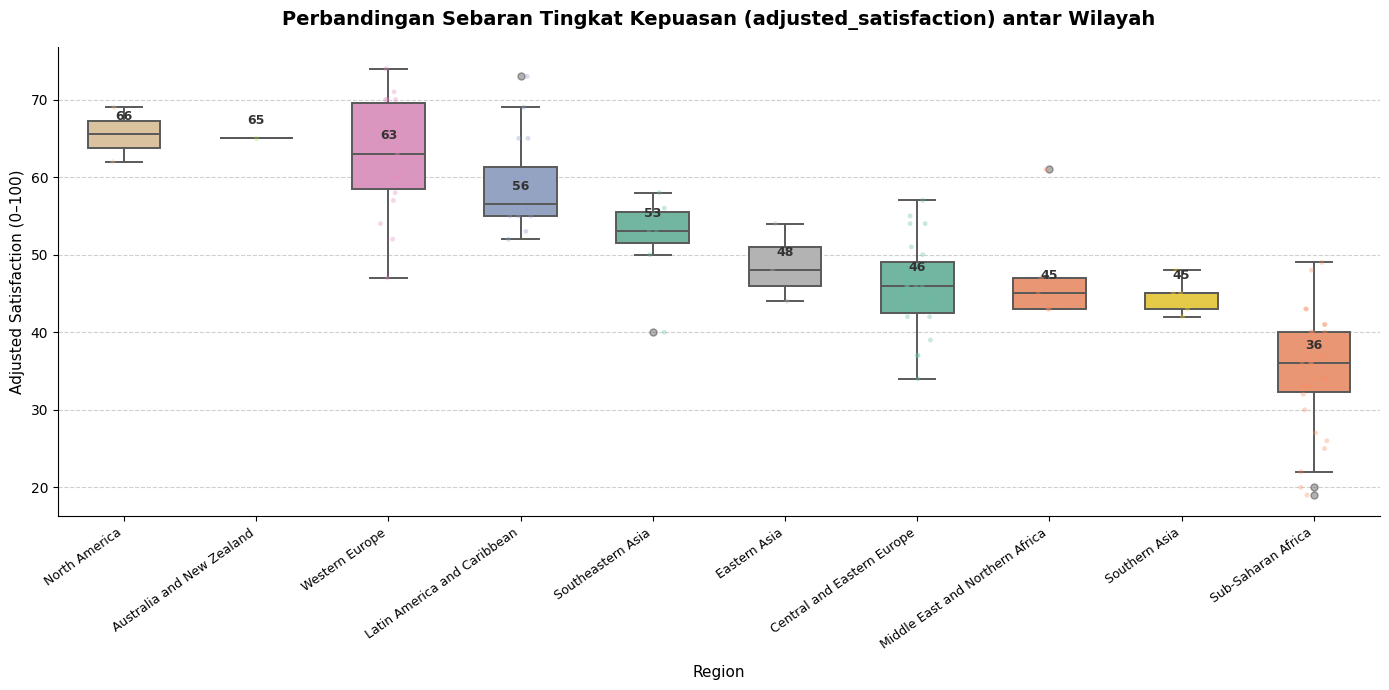

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load dan Persiapan Data ────────────────────────────────────────────────
# Memuat dataset
df = pd.read_csv(
    "Kelas D_Happiness and Satisfaction.csv",
    sep=";",
    decimal=","
)

# Pembersihan data
df.columns = df.columns.str.strip()
df["Region"] = df["Region"].str.strip().str.strip("'")

# Pastikan kolom target numerik
df["adjusted_satisfaction (0-100)"] = pd.to_numeric(
    df["adjusted_satisfaction (0-100)"], errors="coerce"
)
df.dropna(subset=["adjusted_satisfaction (0-100)", "Region"], inplace=True)

# ── 2. Urutkan region berdasarkan median ──────────────────────────────────────
region_order = (
    df.groupby("Region")["adjusted_satisfaction (0-100)"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# ── 3. Plotting ──────────────────────────────────────────────────────────────
palette = sns.color_palette("Set2", n_colors=len(region_order))
fig, ax = plt.subplots(figsize=(14, 7))

# Boxplot (Menggunakan hue untuk menghindari warning)
sns.boxplot(
    data=df,
    x="Region",
    y="adjusted_satisfaction (0-100)",
    hue="Region",
    order=region_order,
    palette=palette,
    legend=False,
    width=0.55,
    linewidth=1.4,
    flierprops=dict(marker="o", markersize=5, linestyle="none",
                    markerfacecolor="gray", alpha=0.6),
    ax=ax
)

# Stripplot (Menggunakan hue untuk menghindari warning)
sns.stripplot(
    data=df,
    x="Region",
    y="adjusted_satisfaction (0-100)",
    hue="Region",
    order=region_order,
    palette=palette,
    legend=False,
    size=3.5,
    alpha=0.35,
    jitter=True,
    ax=ax
)

# ── 4. Anotasi Median ─────────────────────────────────────────────────────────
for i, region in enumerate(region_order):
    median_val = df[df["Region"] == region]["adjusted_satisfaction (0-100)"].median()
    ax.text(i, median_val + 1.5, f"{median_val:.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333")

# ── 5. Estetika ───────────────────────────────────────────────────────────────
ax.set_title("Perbandingan Sebaran Tingkat Kepuasan (adjusted_satisfaction) antar Wilayah",
             fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Region", fontsize=11, labelpad=10)
ax.set_ylabel("Adjusted Satisfaction (0–100)", fontsize=11)

# Mengatur ticks agar tidak muncul warning
ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, rotation=35, ha="right", fontsize=9)

ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()